# 05 · Test evaluation: Sep 17–30, 2026

**Input:** the forecast from `04` (`reports/forecast_2026-09-17_to_2026-09-30_linear_regression.csv`) and the comparison columns from `03`.
**Output:** `data/external/rdu_obs_2026-09-17_to_2026-09-30.csv` (observations of the test window) and the test scores.

This notebook is run only after the forecast was frozen. The observations of the test window are downloaded here for scoring only and are never an input to any model; they are kept in `data/external/`, separate from the training data in `data/raw/`.

## 1. Settings and integrity check

The forecast was saved and its SHA-256 checksum recorded on Oct 4, 2026 (03:30 UTC), before any observation from Sep 17–30 was downloaded. The check below confirms that the frozen file is unchanged and that `04` reproduces it exactly.

In [5]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_dir, *current_dir.parents]
    if (folder / "notebooks").is_dir() and (folder / "requirements.txt").is_file()
)
FORECAST_FILE = PROJECT_ROOT / "reports" / "forecast_2026-09-17_to_2026-09-30_linear_regression.csv"
SAMPLES_FILE = PROJECT_ROOT / "data" / "processed" / "model_samples_2024-03-14_to_2026-09-16.csv.gz"
FROZEN_FILE = PROJECT_ROOT / "scripts" / "results" / "final_forecast_M14.csv"   # frozen before any test data was seen
FROZEN_HASH = PROJECT_ROOT / "scripts" / "results" / "final_forecast_M14.sha256"
TEST_OBS_FILE = PROJECT_ROOT / "data" / "external" / "rdu_obs_2026-09-17_to_2026-09-30.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

NY = "America/New_York"
TEST_START = pd.Timestamp("2026-09-17", tz=NY)
TEST_END = pd.Timestamp("2026-10-01", tz=NY)  # exclusive
NOAA_URL = ("https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/"
            "by-year/2026/psv/GHCNh_USW00013722_2026.psv")


def save_fig(fig, name):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"05_{name}.png", dpi=150, bbox_inches="tight")


forecast = pd.read_csv(FORECAST_FILE)
frozen = pd.read_csv(FROZEN_FILE)
recorded_hash, frozen_at = FROZEN_HASH.read_text().split("\n")[0].split()[0], FROZEN_HASH.read_text().split("\n")[1]
checks = {
    "frozen file unchanged since it was locked": hashlib.sha256(FROZEN_FILE.read_bytes()).hexdigest() == recorded_hash,
    "04 forecast = frozen forecast": np.allclose(forecast["forecast_deg_c"], frozen["temperature_forecast_c"])
                                     and (forecast["hour_local"] == frozen["hour_local"]).all(),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())
print(f"Forecast: {len(forecast)} hours, {forecast['hour_local'].iloc[0]} -> {forecast['hour_local'].iloc[-1]}; {frozen_at}")

,passed
frozen file unchanged since it was locked,True
04 forecast = frozen forecast,True


Forecast: 336 hours, 2026-09-17 00:00 -> 2026-09-30 23:00; frozen at 2026-10-04T03:30:52Z (before downloading Sep 17-30 observations)


## 2. Observations of the test window

Same selection (FM15 reports at minute :51, labelled with their hour) and the same temperature cleaning rules as `02`. NOAA's yearly file can lag by a few hours, so the last hours of Sep 30 may still be missing.

In [6]:
noaa = pd.read_csv(NOAA_URL, sep="|", low_memory=False)
noaa = noaa[noaa["temperature_Report_Type"].eq("FM15") & noaa["Minute"].eq(51)].copy()
noaa.index = pd.DatetimeIndex(pd.to_datetime(noaa["DATE"], utc=True).dt.floor("h"), name="hour_utc")  # hh:51 -> hh
noaa = noaa[~noaa.index.duplicated()].sort_index()

# Same temperature cleaning as 02 (one day of margin so the spike checks have neighbours)
grid = pd.date_range((TEST_START - pd.Timedelta(days=1)).tz_convert("UTC"), (TEST_END + pd.Timedelta(days=1)).tz_convert("UTC"),
                     freq="h", inclusive="left", name="hour_utc")
obs = noaa.reindex(grid)
ISD_SOURCES = {"313", "314", "315", "322", "335", "343", "344", "346"}
LEGACY_SOURCES = {"220", "221", "222", "223", "347", "348"}
LIMITS = {"temperature": (-30, 45), "dew_point_temperature": (-40, 35), "altimeter": (950, 1060)}
code = lambda s: s.astype("string").str.replace(r"\.0$", "", regex=True).fillna("")


def bad_quality(v):
    source, quality = code(obs[f"{v}_Source_Code"]), code(obs[f"{v}_Quality_Code"])
    return ((source.isin(ISD_SOURCES) & quality.isin({"2", "3", "6", "7"}))
            | (source.isin(LEGACY_SOURCES) & quality.isin({"2", "3", "5"})) | quality.str.contains(r"[a-z]", regex=True))


def spike_size(x):
    jump_in, jump_out = x - x.shift(1), x - x.shift(-1)
    return np.minimum(jump_in.abs(), jump_out.abs()).where(np.sign(jump_in) == np.sign(jump_out), 0)


values = {v: pd.to_numeric(obs[v], errors="coerce") for v in LIMITS}
screened = {v: values[v].mask(bad_quality(v) | ~values[v].between(*LIMITS[v])) for v in LIMITS}
corrupted = ((spike_size(screened["temperature"]) > 4).astype(int) + (spike_size(screened["dew_point_temperature"]) > 5).astype(int)
             + (spike_size(screened["altimeter"]) > 3).astype(int)) >= 2
rejected = (bad_quality("temperature") | ~values["temperature"].between(*LIMITS["temperature"]) | corrupted
            | (spike_size(screened["temperature"]) > 8)) & values["temperature"].notna()

test_hours = grid[(grid >= TEST_START) & (grid < TEST_END)]
actual = pd.DataFrame({"hour_local": test_hours.tz_convert(NY).strftime("%Y-%m-%d %H:%M"),
                       "observed_deg_c": values["temperature"].mask(rejected).reindex(test_hours)}, index=test_hours)
TEST_OBS_FILE.parent.mkdir(parents=True, exist_ok=True)
actual.to_csv(TEST_OBS_FILE, index_label="hour_utc")
print(f"Saved {TEST_OBS_FILE.relative_to(PROJECT_ROOT)}: {actual['observed_deg_c'].notna().sum()} of {len(actual)} hours observed, "
      f"{int(rejected.reindex(test_hours).sum())} rejected; last observation {actual.dropna().iloc[-1]['hour_local']}")

Saved data/external/rdu_obs_2026-09-17_to_2026-09-30.csv: 322 of 336 hours observed, 0 rejected; last observation 2026-09-30 09:00


## 3. Scores

All five methods are scored on the same observed hours. This is a single 14-day forecast, so the numbers are much noisier than the validation results in `04` (108 forecasts).

In [7]:
samples = pd.read_csv(SAMPLES_FILE, parse_dates=["run_day"])
final = samples[samples["run_day"].eq(pd.Timestamp("2026-09-16"))].set_index("target_local")
table = forecast.set_index("hour_local").join(final[["lead_day", "persistence", "ecmwf_lagged_mean"]])
table["observed"] = actual.set_index("hour_local")["observed_deg_c"]
methods = {"Persistence": "persistence", "Historical average": "historical_average_deg_c",
           "ECMWF raw": "ecmwf_raw_deg_c", "ECMWF lagged mean": "ecmwf_lagged_mean", "Linear regression": "forecast_deg_c"}
scored = table.dropna(subset=["observed"])
errors = pd.DataFrame({name: scored["observed"] - scored[column] for name, column in methods.items()})

summary = pd.DataFrame({"MAE": errors.abs().mean(), "RMSE": np.sqrt((errors ** 2).mean()), "bias (obs - forecast)": errors.mean()})
lr = summary.loc["Linear regression", "MAE"]
summary["LR improvement (% lower MAE)"] = 100 * (1 - lr / summary["MAE"])
print(f"Scored hours: {len(scored)} of {len(table)}")
display(summary.round(2))

by_day = errors.abs().groupby(scored["lead_day"].to_numpy()).mean().T
by_day.columns.name = "forecast day"
display(by_day.round(2))

Scored hours: 322 of 336


,MAE,RMSE,bias (obs - forecast),LR improvement (% lower MAE)
Persistence,4.06,4.96,-1.36,33.64
Historical average,3.64,4.42,-0.22,25.98
ECMWF raw,3.27,4.07,-0.03,17.61
ECMWF lagged mean,2.83,3.68,-1.00,4.85
Linear regression,2.69,3.67,-1.31,0.00


forecast day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,2.52,4.50,2.95,2.80,4.00,2.92,6.64,7.21,6.95,5.23,3.56,2.85,1.95,0.95
Historical average,3.42,5.01,3.67,3.77,4.52,1.72,5.37,5.84,5.63,4.05,2.29,1.88,1.24,1.06
ECMWF raw,1.40,1.29,1.71,1.66,1.67,1.57,6.45,6.69,4.12,3.52,3.72,3.73,5.33,2.43
ECMWF lagged mean,1.20,1.44,2.35,1.80,1.77,1.38,6.37,6.54,5.15,3.69,2.13,1.40,2.26,1.21
Linear regression,1.15,1.17,1.99,1.62,1.78,1.32,6.43,6.68,5.33,3.45,1.79,1.36,1.48,1.44


## 4. Forecast vs. observations

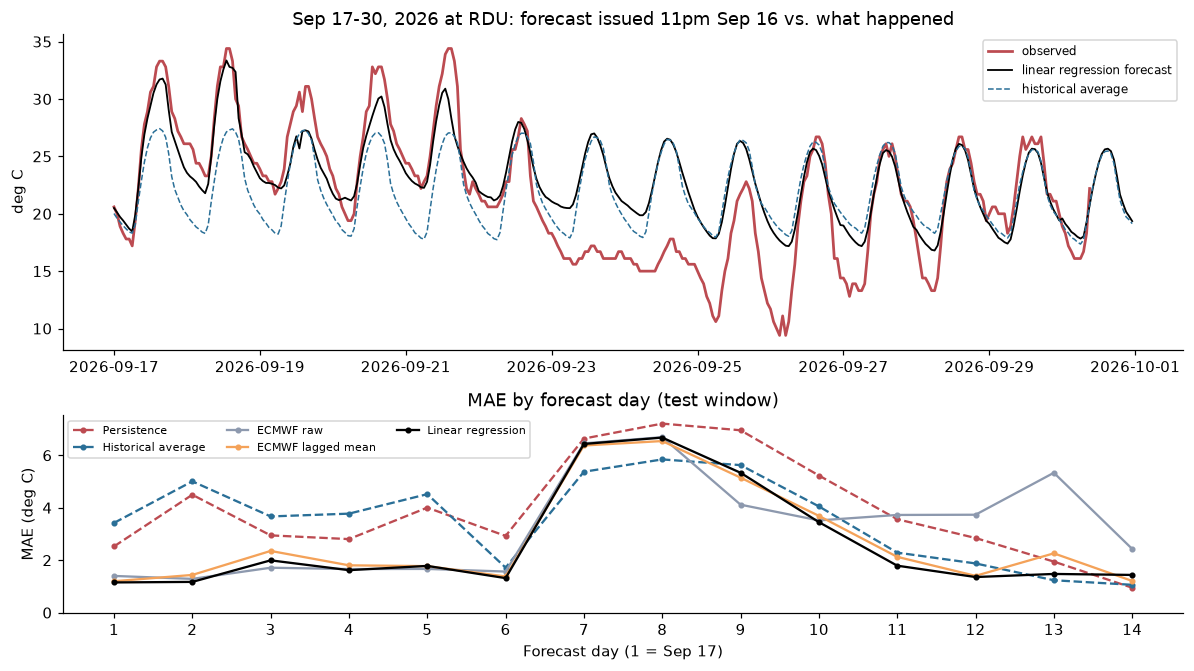

date,2026-09-17,2026-09-18,2026-09-19,2026-09-20,2026-09-21,2026-09-22,2026-09-23,2026-09-24,2026-09-25,2026-09-26,2026-09-27,2026-09-28,2026-09-29,2026-09-30
observed,25.7,27.5,26.1,26.0,26.6,22.4,16.5,16.0,16.2,17.9,19.6,20.3,22.5,17.7
forecast_deg_c,25.0,26.6,24.2,25.0,25.2,23.6,23.0,22.6,21.6,20.9,20.9,21.0,21.1,21.2
historical_average_deg_c,22.6,22.5,22.4,22.2,22.1,22.0,21.9,21.8,21.8,21.8,21.9,21.7,21.3,20.9


In [8]:
when = pd.to_datetime(table.index)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), gridspec_kw={"height_ratios": [1.6, 1]})
axes[0].plot(when, table["observed"], color="#bc4b51", linewidth=1.8, label="observed")
axes[0].plot(when, table["forecast_deg_c"], color="black", linewidth=1.2, label="linear regression forecast")
axes[0].plot(when, table["historical_average_deg_c"], color="#2a6f97", linestyle="--", linewidth=1, label="historical average")
axes[0].set(title="Sep 17-30, 2026 at RDU: forecast issued 11pm Sep 16 vs. what happened", ylabel="deg C")
axes[0].legend(fontsize=8)
styles = {"Persistence": ("#bc4b51", "--"), "Historical average": ("#2a6f97", "--"), "ECMWF raw": ("#8d99ae", "-"),
          "ECMWF lagged mean": ("#f4a259", "-"), "Linear regression": ("black", "-")}
for name, (color, line) in styles.items():
    axes[1].plot(by_day.columns, by_day.loc[name], color=color, linestyle=line, marker="o", markersize=3, label=name)
axes[1].set(title="MAE by forecast day (test window)", xlabel="Forecast day (1 = Sep 17)", ylabel="MAE (deg C)", ylim=(0, None))
axes[1].set_xticks(range(1, 15))
axes[1].legend(fontsize=7, ncol=3)
fig.tight_layout()
save_fig(fig, "test_forecast_vs_observed")
plt.show()

daily = table.assign(date=table.index.str[:10]).groupby("date")[["observed", "forecast_deg_c", "historical_average_deg_c"]].mean()
display(daily.round(1).T)